### 리터러시(literacy, 문해력) : 글을 읽고, 읽은 내용을 이해하는 능력

1. 데이터 리터러시(데이터 문해력)
- 데이터를 활용해 결정을 내리고, 효과적으로 의사소통하는 능력
- 데이터를 읽고 이해한 것을 바탕으로 분석 결과를 전달하는 능력
- 세부 역량으로는 데이터 수집, 관리, 가공 및 분석, 시각화, 해석 및 기획 역량

2. 데이터 시각화(Data Visualization) - 그래프(Graph)
- 시각화는 목적에 맞는 그래프 선정이 중요함

3. 대표적인 시각화 파이썬 라이브러리
- 맷플롭립(Matplotlib, plt) - Mathematics plot library, 기본이면서 대중적임
- 씨본(Seaborn, sns) - 맷플롭립을 사용하기 편하게 만듦
- 플롯리(Plotly, px) - 상호작용이 특징

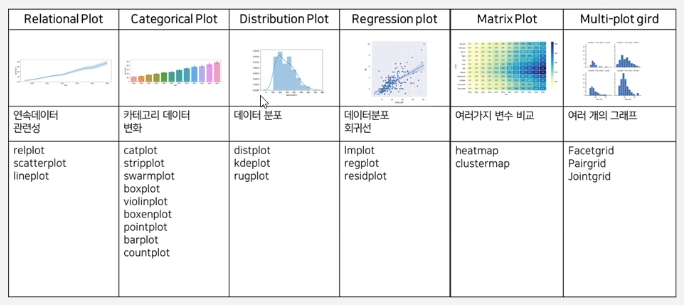

### [문제] 자동차 연비 데이터셋(mpg.csv)에서, 배기량(displ)에 따른 고속도로 연비(hwy)의 분포를 시각화하고 싶음
- 맷플롭립
- 씨본

In [1]:
import pandas as pd
df = pd.read_csv('mpg.csv')
df.head()

,manufacturer,model,displ,year,cyl,trans,drv,cty,hwy,fl,category
0,audi,a4,1.8,1999,4,auto(l5),f,18,29,p,compact
1,audi,a4,1.8,1999,4,manual(m5),f,21,29,p,compact
2,audi,a4,2.0,2008,4,manual(m6),f,20,31,p,compact
3,audi,a4,2.0,2008,4,auto(av),f,21,30,p,compact
4,audi,a4,2.8,1999,6,auto(l5),f,16,26,p,compact


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 234 entries, 0 to 233
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   manufacturer  234 non-null    str    
 1   model         234 non-null    str    
 2   displ         234 non-null    float64
 3   year          234 non-null    int64  
 4   cyl           234 non-null    int64  
 5   trans         234 non-null    str    
 6   drv           234 non-null    str    
 7   cty           234 non-null    int64  
 8   hwy           234 non-null    int64  
 9   fl            234 non-null    str    
 10  category      234 non-null    str    
dtypes: float64(1), int64(4), str(6)
memory usage: 20.2 KB


In [3]:
df.describe()

,displ,year,cyl,cty,hwy
count,234.000000,234.000000,234.000000,234.000000,234.000000
mean,3.471795,2003.500000,5.888889,16.858974,23.440171
std,1.291959,4.509646,1.611534,4.255946,5.954643
min,1.600000,1999.000000,4.000000,9.000000,12.000000
25%,2.400000,1999.000000,4.000000,14.000000,18.000000
50%,3.300000,2003.500000,6.000000,17.000000,24.000000
75%,4.600000,2008.000000,8.000000,19.000000,27.000000
max,7.000000,2008.000000,8.000000,35.000000,44.000000


In [2]:
X = df['displ'] # 배기량
y = df['hwy'] # 고속도로 연비

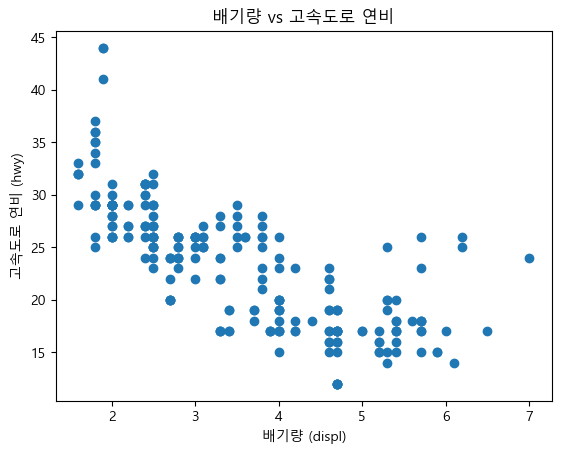

In [3]:
from matplotlib import rc
import matplotlib.pyplot as plt
rc('font', family='Malgun Gothic') # 한글 폰트 설정
plt.scatter(X, y)
plt.xlabel('배기량 (displ)')
plt.ylabel('고속도로 연비 (hwy)')
plt.title('배기량 vs 고속도로 연비')
# plt.xlim(3, 6) # x축 범위 설정
# plt.ylim(10, 30) # y축 범위 설정
plt.show()

### Seaborn을 활용한 그래프 작성하기
- 씨본은 맷플롭립을 기반으로 만들어진 라이브러리로, 맷플롭립보다 사용하기 편리한 인터페이스를 제공함
- 다양한 그래프 유형을 지원하며, 데이터프레임과 함께 사용하기 좋음

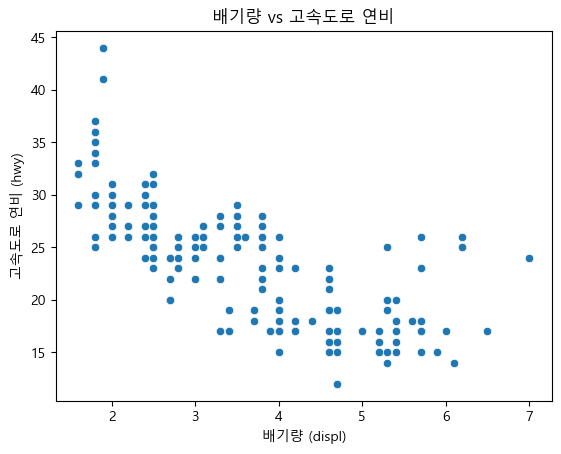

In [4]:
import seaborn as sns
sns.scatterplot(x='displ', y='hwy', data=df)
plt.xlabel('배기량 (displ)')
plt.ylabel('고속도로 연비 (hwy)')
plt.title('배기량 vs 고속도로 연비')
plt.show()

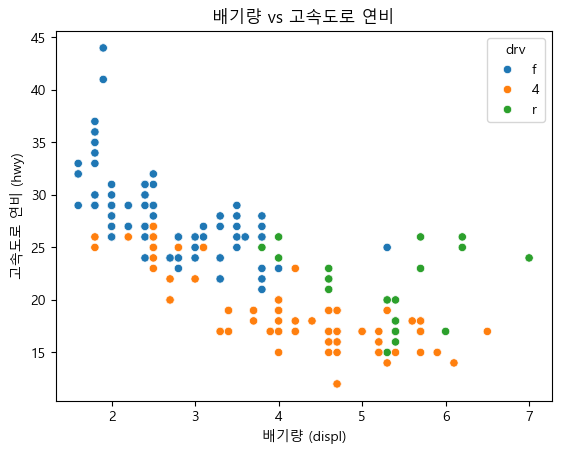

In [5]:
sns.scatterplot(x='displ', y='hwy', data=df, hue='drv') # hue 옵션으로 drv 컬럼의 값에 따라 색상 구분
plt.xlabel('배기량 (displ)')
plt.ylabel('고속도로 연비 (hwy)')
plt.title('배기량 vs 고속도로 연비')
plt.show()

### 데이터 시각화(Data Visualization) - 그래프(Graph)
- 시각화는 목적에 맞는 그래프 선정이 중요함

1. 대표적인 시각화 파이썬 라이브러리
- 맷플롭립(Matplotlib, plt): Mathematics plot library, 기본이면서 대중적임
- 씨본(Seaborn, sns): 맷플롭립을 사용하기 편하게 만듦
- 플롯리(Plotly, px): 상호작용이 특징

2. [문제] 자동차 연비 데이터셋(mpg.csv)에서 구동방식(drv)별 고속도로 연비(hwy) 평균을 비교
- 구동방식별로 그룹핑
- 그룹별 고속도로 연비 평균 계산
- 연비 평균 비교 그래프

In [12]:
import pandas as pd
df = pd.read_csv('mpg.csv', header=0) # header=0 : 첫 번째 행을 열 이름으로 사용
df.head()

,manufacturer,model,displ,year,cyl,trans,drv,cty,hwy,fl,category
0,audi,a4,1.8,1999,4,auto(l5),f,18,29,p,compact
1,audi,a4,1.8,1999,4,manual(m5),f,21,29,p,compact
2,audi,a4,2.0,2008,4,manual(m6),f,20,31,p,compact
3,audi,a4,2.0,2008,4,auto(av),f,21,30,p,compact
4,audi,a4,2.8,1999,6,auto(l5),f,16,26,p,compact


In [13]:
print(df['drv'].unique()) # 고유값 확인
print(df['drv'].value_counts()) # 고유값별 빈도수 확인

<StringArray>
['f', '4', 'r']
Length: 3, dtype: str
drv
f    106
4    103
r     25
Name: count, dtype: int64


In [14]:
df_mpg = df.groupby('drv', as_index=False).agg(mean_hwy=('hwy', 'mean'))
df_mpg

,drv,mean_hwy
0,4,19.174757
1,f,28.160377
2,r,21.000000


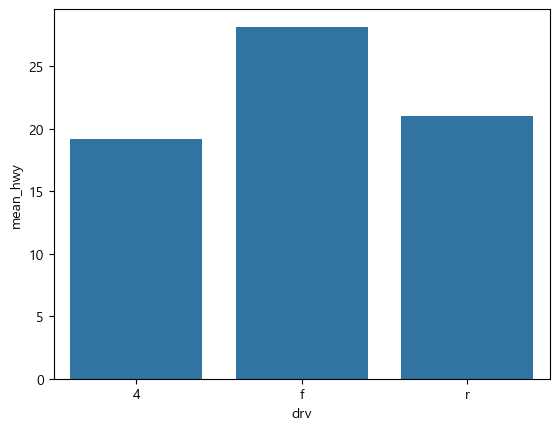

In [16]:
import seaborn as sns
sns.barplot(data=df_mpg, x='drv', y='mean_hwy')
plt.show()

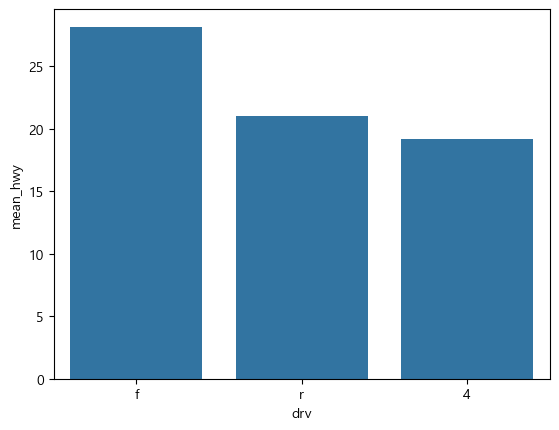

In [ ]:
df_mpg = df_mpg.sort_values('mean_hwy', ascending=False) # mean_hwy 기준으로 내림차순 정렬, ascending=False : 내림차순, ascending=True : 오름차순
sns.barplot(data=df_mpg, x='drv', y='mean_hwy')
plt.show()

### 빈도 그래프 - 범주형 데이터의 빈도(횟수)를 시각화하는 그래프
- 막대 그래프(Bar plot): 범주별 빈도를 막대의 높이로 표현하는 그래프
- 파이 그래프(Pie chart): 범주별 빈도를 원형으로 표현하는 그래프
- 카운트 그래프(Count plot): 범주별 빈도를 막대의 높이로 표현하는 그래프, 데이터프레임과 함께 사용하기 좋음

In [6]:
import pandas as pd
df = pd.read_csv('mpg.csv', header=0) # header=0 : 첫 번째 행을 열 이름으로 사용
df.head()

,manufacturer,model,displ,year,cyl,trans,drv,cty,hwy,fl,category
0,audi,a4,1.8,1999,4,auto(l5),f,18,29,p,compact
1,audi,a4,1.8,1999,4,manual(m5),f,21,29,p,compact
2,audi,a4,2.0,2008,4,manual(m6),f,20,31,p,compact
3,audi,a4,2.0,2008,4,auto(av),f,21,30,p,compact
4,audi,a4,2.8,1999,6,auto(l5),f,16,26,p,compact


In [9]:
df_mpg =df.groupby('drv', as_index=False).agg(n=('drv', 'count'))
df_mpg

,drv,n
0,4,103
1,f,106
2,r,25


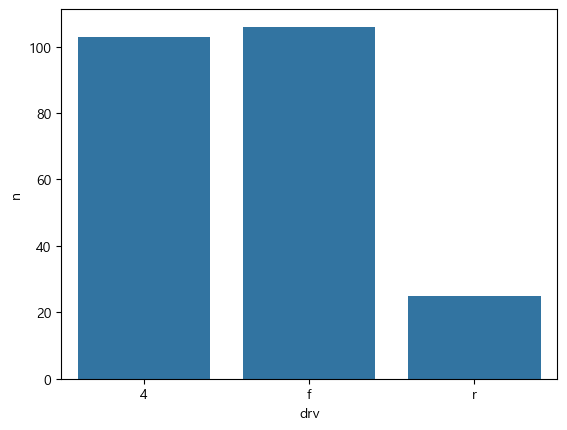

In [10]:
import seaborn as sns
sns.barplot(data=df_mpg, x='drv', y='n')
plt.show()

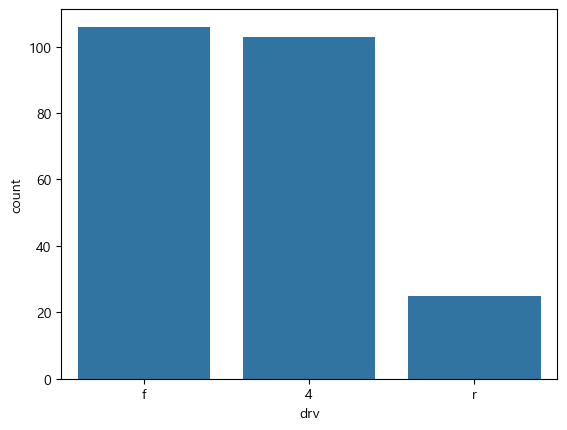

In [ ]:
sns.countplot(x='drv', data=df) # df 데이터프레임에서 drv 컬럼의 값별 빈도수를 막대 그래프로 표현
plt.show()

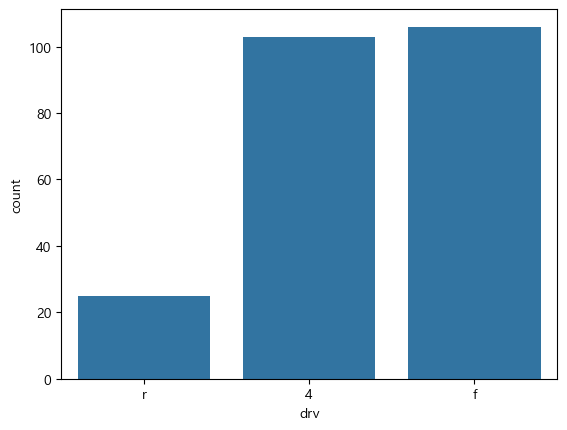

In [16]:
sns.countplot(x='drv', data=df, order=['r', '4', 'f']) # order 옵션으로 x축 범주 순서 지정
plt.show()

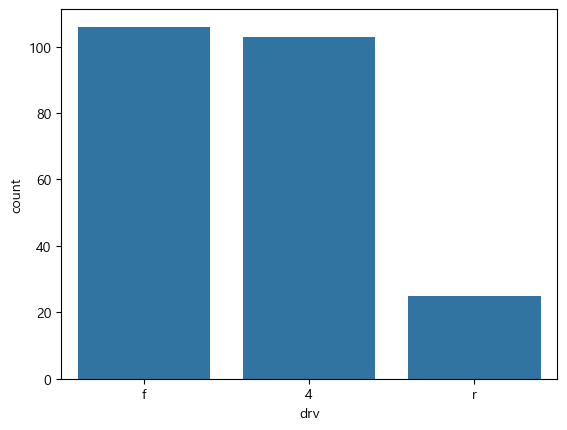

In [17]:
sns.countplot(x='drv', data=df, order=df['drv'].value_counts().index) # order 옵션으로 x축 범주 순서를 빈도수 기준으로 지정
plt.show()

- date : 날짜(연-월-일)
- pce(Personal Consumption Expenditure) : 개인소비지출 물가지수
- pop(POPulation, in thousands) : 인구(천명 단위)
- psavert(Personal Saving Rate) : 개인저축율
- uempmed(median duration of unemployment, in weeks) : 실업지속기간(주 단위)
- unemployment(number of unemployed in thousands) : 실업자수(천명 단위)

In [18]:
import pandas as pd
df = pd.read_csv('economics.csv', header=0) # header=0 : 첫 번째 행을 열 이름으로 사용
df.head()

,date,pce,pop,psavert,uempmed,unemploy
0,1967-07-01,507.4,198712,12.5,4.5,2944
1,1967-08-01,510.5,198911,12.5,4.7,2945
2,1967-09-01,516.3,199113,11.7,4.6,2958
3,1967-10-01,512.9,199311,12.5,4.9,3143
4,1967-11-01,518.1,199498,12.5,4.7,3066


In [21]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 574 entries, 0 to 573
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   date      574 non-null    str    
 1   pce       574 non-null    float64
 2   pop       574 non-null    int64  
 3   psavert   574 non-null    float64
 4   uempmed   574 non-null    float64
 5   unemploy  574 non-null    int64  
dtypes: float64(3), int64(2), str(1)
memory usage: 27.0 KB


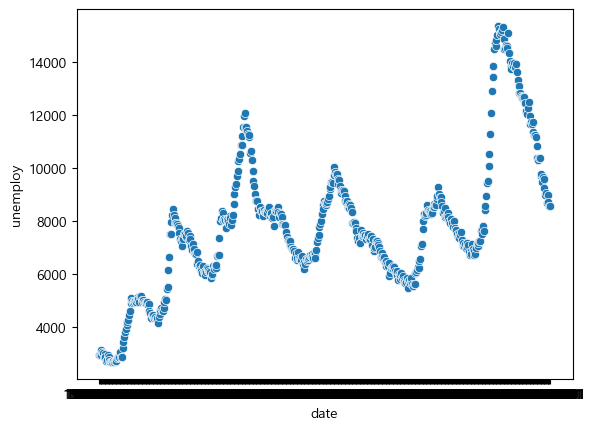

In [19]:
import seaborn as sns
sns.scatterplot(x='date', y='unemploy', data=df)
plt.show()

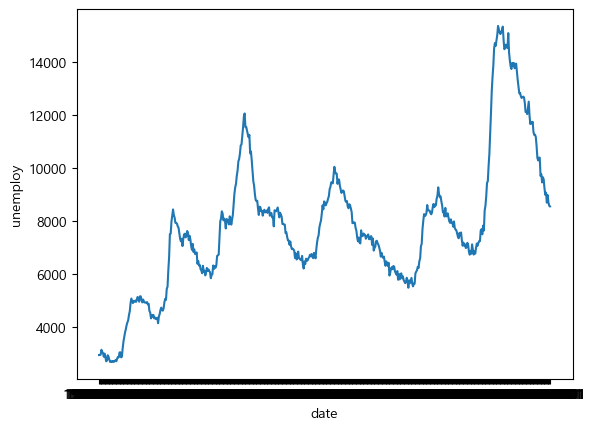

In [20]:
sns.lineplot(x='date', y='unemploy', data=df)
plt.show()

In [24]:
# 년도별로 보이기
df['date2'] = pd.to_datetime(df['date']) # date 컬럼을 datetime 형식으로 변환하여 date2 컬럼에 저장
df['year'] = df['date2'].dt.year # date2 컬럼에서 연도만 추출하여 year 컬럼에 저장
df


,date,pce,pop,psavert,uempmed,unemploy,date2,year
0,1967-07-01,507.4,198712,12.5,4.5,2944,1967-07-01,1967
1,1967-08-01,510.5,198911,12.5,4.7,2945,1967-08-01,1967
2,1967-09-01,516.3,199113,11.7,4.6,2958,1967-09-01,1967
3,1967-10-01,512.9,199311,12.5,4.9,3143,1967-10-01,1967
4,1967-11-01,518.1,199498,12.5,4.7,3066,1967-11-01,1967
...,...,...,...,...,...,...,...,...
569,2014-12-01,12122.0,320201,5.0,12.6,8688,2014-12-01,2014
570,2015-01-01,12080.8,320367,5.5,13.4,8979,2015-01-01,2015
571,2015-02-01,12095.9,320534,5.7,13.1,8705,2015-02-01,2015
572,2015-03-01,12161.5,320707,5.2,12.2,8575,2015-03-01,2015


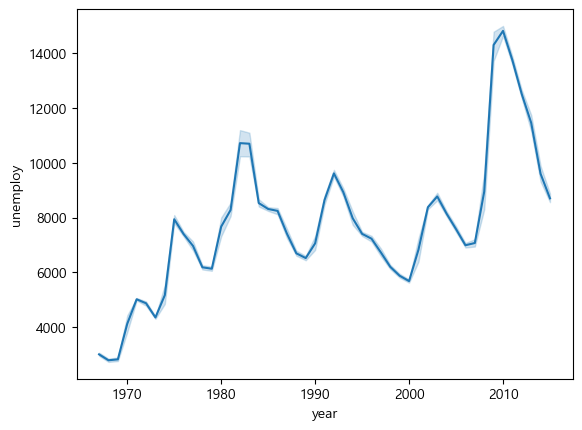

In [26]:
sns.lineplot(x='year', y='unemploy', data=df, errorbar=('ci', 95)) # errorbar 옵션으로 신뢰구간 표시, ('ci', 95) : 95% 신뢰구간
plt.show()

### 이상치 분포 확인(Box plot)
- 이상치(outlier)는 데이터에서 다른 값들과 현저히 다른 값을 의미함
- 이상치 분포를 확인하는 방법 중 하나는 박스 플롯(Box plot)을 사용하는 것임
- 박스 플롯은 데이터의 중앙값, 사분위수,최소값, 최대값, 이상치를 시각적으로 표현하는 그래프임
- 박스 플롯을 통해 데이터의 분포와 이상치의 위치를 쉽게 파악할 수 있음

In [1]:
import pandas as pd
df = pd.read_csv('mpg.csv', header=0) # header=0 : 첫 번째 행을 열 이름으로 사용
df.head()

,manufacturer,model,displ,year,cyl,trans,drv,cty,hwy,fl,category
0,audi,a4,1.8,1999,4,auto(l5),f,18,29,p,compact
1,audi,a4,1.8,1999,4,manual(m5),f,21,29,p,compact
2,audi,a4,2.0,2008,4,manual(m6),f,20,31,p,compact
3,audi,a4,2.0,2008,4,auto(av),f,21,30,p,compact
4,audi,a4,2.8,1999,6,auto(l5),f,16,26,p,compact


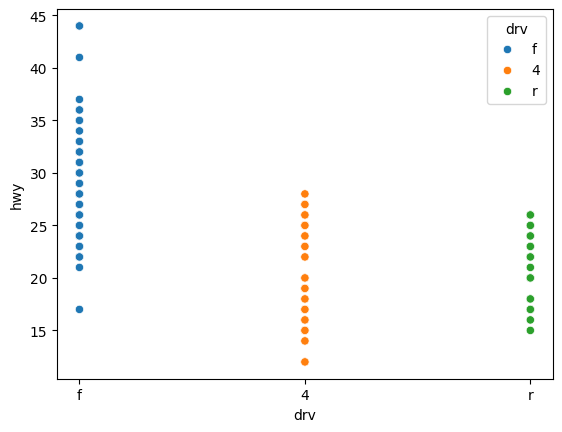

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.scatterplot(x='drv', y='hwy', data=df, hue='drv') # hue 옵션으로 drv 컬럼의 값에 따라 색상 구분
plt.show()

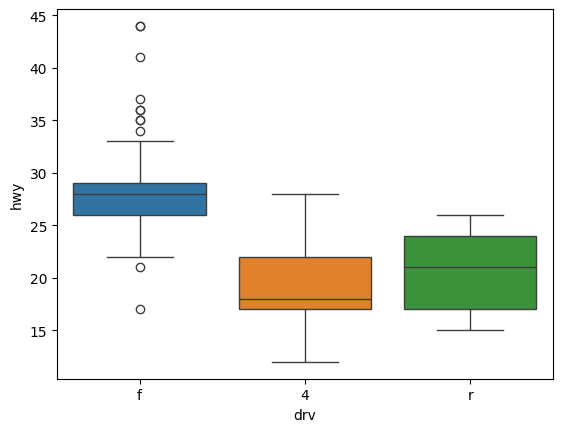

In [ ]:
sns.boxplot(x='drv', y='hwy', data=df, hue='drv', whis=1.5) # drv 컬럼의 값별로 hwy 컬럼의 분포를 상자 그림으로 표현
plt.show()

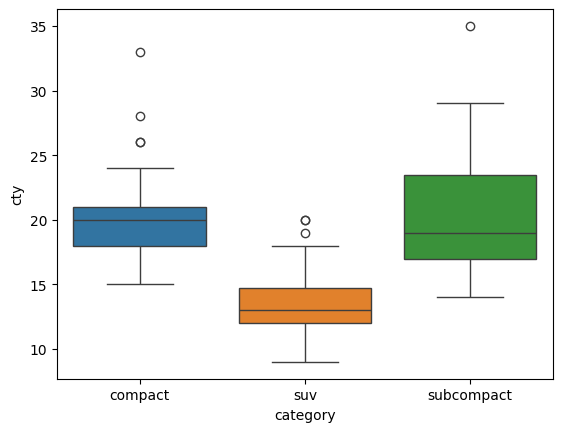

In [6]:
# 자동차 종류별 도시 연비 분포
df_category = df.query("category in ['compact', 'subcompact', 'suv']") # category 컬럼의 값이 compact 또는 suv인 행만 추출하여 df_category 데이터프레임에 저장
sns.boxplot(x='category', y='cty', data=df_category, hue='category', whis=1.5) # category 컬럼의 값별로 cty 컬럼의 분포를 상자 그림으로 표현
plt.show()